In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

In [31]:
df = pd.read_csv('moral_machine_responses.csv')

df.replace(np.nan, 'no especificado', inplace=True)

,outcome_id,country,scenario_type,character_group,saved,dies_if_car_swerves,pedestrians_vs_pedestrians,is_passengers,crossing_legality,num_characters,...,large_man,criminal,male_executive,female_executive,female_athlete,male_athlete,female_doctor,male_doctor,dog,cat
0,2223jMWDEGNeszivb,CHE,Utilitarian,More,0,0,1,0,2,5,...,0,1,1,0,1,0,0,0,1,0
1,2225giMabFAayqtuZ,USA,Fitness,Fit,1,0,0,0,2,4,...,0,0,0,0,0,0,0,0,0,0
2,2229A3nHWnXQBFMf5,ITA,Fitness,Fat,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
3,2229pfh4f9FoGARtg,ARG,Species,Pets,1,0,1,0,1,5,...,0,0,0,0,0,0,0,0,2,3
4,2229sLNgv45TmJLtt,RUS,Age,Old,0,0,0,0,1,4,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
600212,8FcQ967yjiTY3QdnE,FRA,Random,Rand,0,0,0,0,2,4,...,0,0,0,0,1,0,1,0,1,0
600213,8FcReymwMknSfnwnd,RUS,Fitness,Fat,0,0,1,0,2,2,...,1,0,0,0,0,0,0,0,0,0
600214,8FcY5E7upW2aARCRM,USA,Utilitarian,Less,0,0,0,0,2,4,...,0,1,0,0,0,0,1,0,0,1
600215,8FceiSHKu36BDgGXu,USA,Social Status,High,1,0,0,0,0,4,...,0,0,0,1,0,0,0,0,0,0


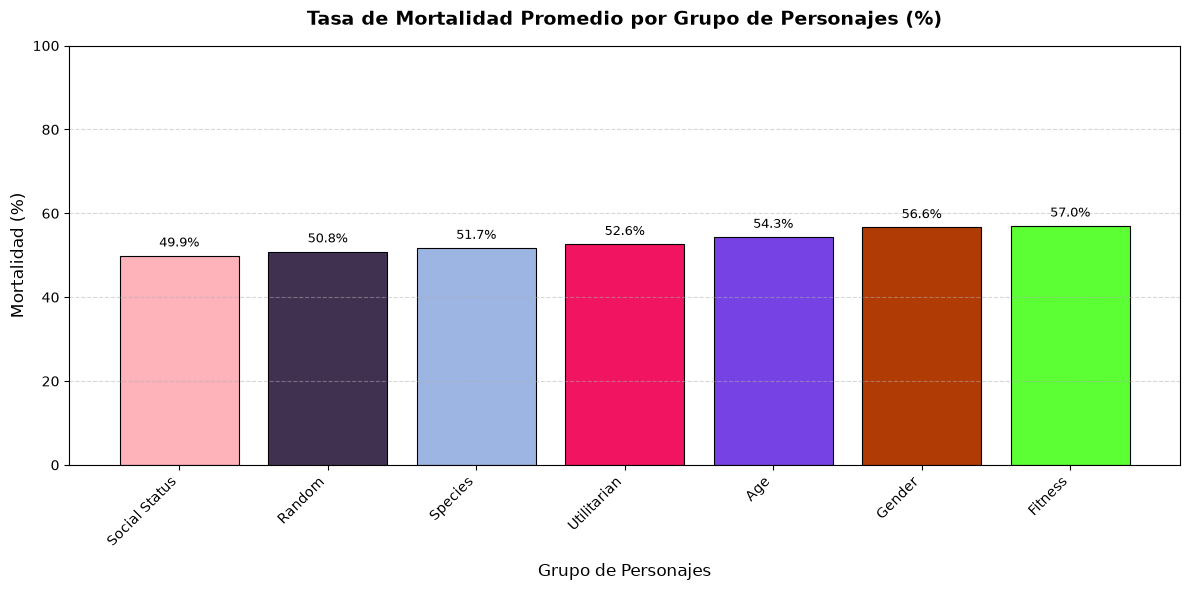

In [32]:
# 1. Matriz de mortalidad
# 1. Tu cálculo de la mortalidad por grupo
mortalidad_matriz = (1 - df.groupby(['scenario_type'])['saved'].mean()) * 100

# Ordenamos los valores de mayor a menor mortalidad para una mejor lectura visual
mortalidad_matriz = mortalidad_matriz.sort_values(ascending=True)

# 2. Generar colores aleatorios (RGB) para cada barra
np.random.seed()  # Cambia en cada ejecución para colores nuevos
num_grupos = len(mortalidad_matriz)
colores_random = np.random.rand(num_grupos, 3)

# 3. Crear la figura y el gráfico
plt.figure(figsize=(12, 6))
barras = plt.bar(
    mortalidad_matriz.index,
    mortalidad_matriz.values,
    color=colores_random,
    edgecolor='black',
    linewidth=0.8,
)

# 4. Personalización del gráfico
plt.title(
    'Tasa de Mortalidad Promedio por Grupo de Personajes (%)',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Grupo de Personajes', fontsize=12, labelpad=10)
plt.ylabel('Mortalidad (%)', fontsize=12)
plt.ylim(0, 100)  # La mortalidad va de 0% a 100%
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 5. Agregar el valor numérico exacto sobre cada barra
for barra in barras:
    yval = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2.0,
        yval + 1.5,
        f'{yval:.1f}%',
        ha='center',
        va='bottom',
        fontsize=9,
    )

plt.tight_layout()
plt.show()

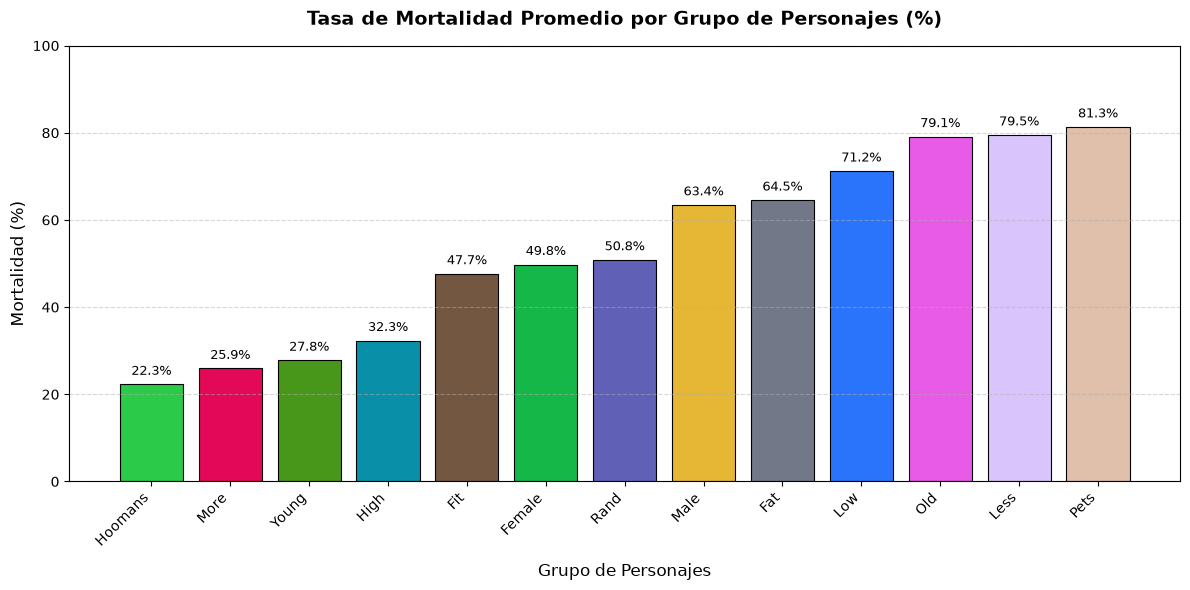

In [33]:
# 1. Matriz de mortalidad
# 1. Tu cálculo de la mortalidad por grupo
mortalidad_matriz = (1 - df.groupby(['character_group'])['saved'].mean()) * 100

# Ordenamos los valores de mayor a menor mortalidad para una mejor lectura visual
mortalidad_matriz = mortalidad_matriz.sort_values(ascending=True)

# 2. Generar colores aleatorios (RGB) para cada barra
np.random.seed()  # Cambia en cada ejecución para colores nuevos
num_grupos = len(mortalidad_matriz)
colores_random = np.random.rand(num_grupos, 3)

# 3. Crear la figura y el gráfico
plt.figure(figsize=(12, 6))
barras = plt.bar(
    mortalidad_matriz.index,
    mortalidad_matriz.values,
    color=colores_random,
    edgecolor='black',
    linewidth=0.8,
)

# 4. Personalización del gráfico
plt.title(
    'Tasa de Mortalidad Promedio por Grupo de Personajes (%)',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Grupo de Personajes', fontsize=12, labelpad=10)
plt.ylabel('Mortalidad (%)', fontsize=12)
plt.ylim(0, 100)  # La mortalidad va de 0% a 100%
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 5. Agregar el valor numérico exacto sobre cada barra
for barra in barras:
    yval = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2.0,
        yval + 1.5,
        f'{yval:.1f}%',
        ha='center',
        va='bottom',
        fontsize=9,
    )

plt.tight_layout()
plt.show()

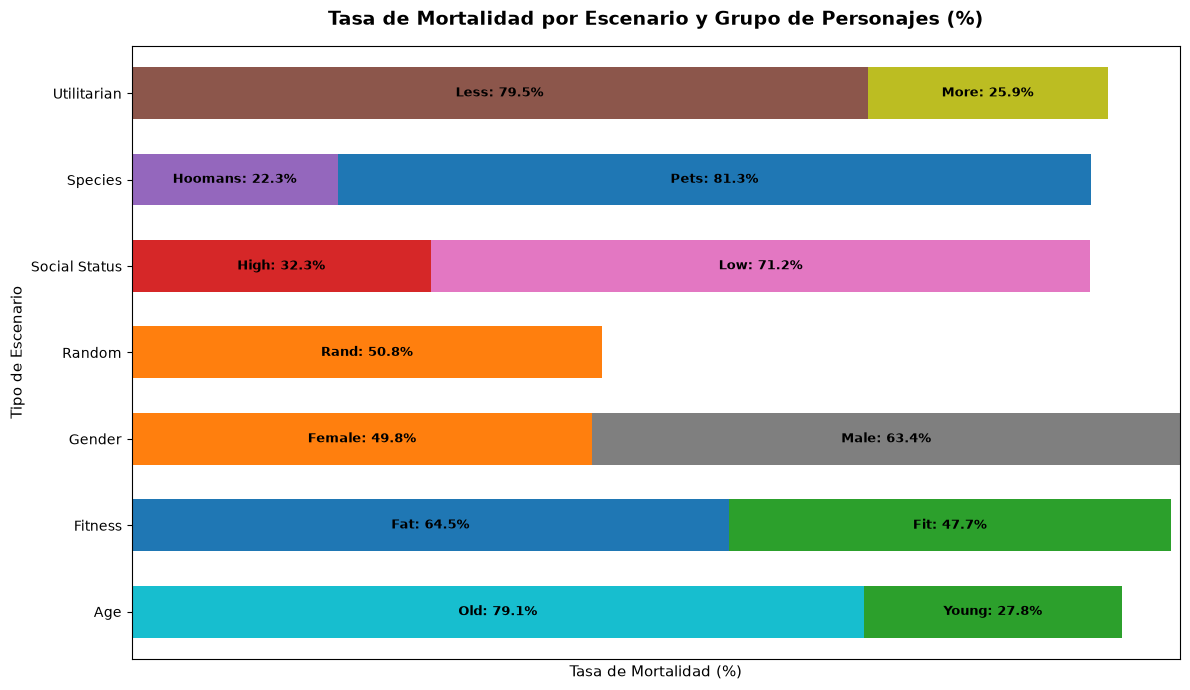

In [34]:
# 1. Matriz de mortalidad
mortalidad_matriz = ((1 - df.groupby(['scenario_type', 'character_group'])['saved'].mean()) * 100).unstack()

fig, ax = plt.subplots(figsize=(12, 7))

# 2. Graficar barras apiladas
mortalidad_matriz.plot(kind='barh', ax=ax, stacked=True, width=0.6, legend=False)

plt.title('Tasa de Mortalidad por Escenario y Grupo de Personajes (%)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tasa de Mortalidad (%)', fontsize=11, )
plt.ylabel('Tipo de Escenario', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.xticks([])

# --- BUCLE PARA AÑADIR NOMBRE Y PORCENTAJE A CADA BARRA ---
for container in ax.containers:
    nombre_grupo = container.get_label()  # Nombre del character_group
    
    for bar in container:
        ancho = bar.get_width()  # Valor del porcentaje
        
        # Filtramos solo las barras que tienen datos (> 0 y no NaN)
        if ancho > 0 and not pd.isna(ancho):
            pos_x = bar.get_x() + ancho / 2  # Centrado en el ancho de la barra
            pos_y = bar.get_y() + bar.get_height() / 2  # Centrado en el alto de la barra
            
            ax.text(
                pos_x, pos_y, 
                f"{nombre_grupo}: {ancho:.1f}%", 
                va='center', 
                ha='center', 
                fontsize=9, 
                fontweight='bold'
            )
# --------------------------------------------------------

plt.tight_layout()
plt.show()

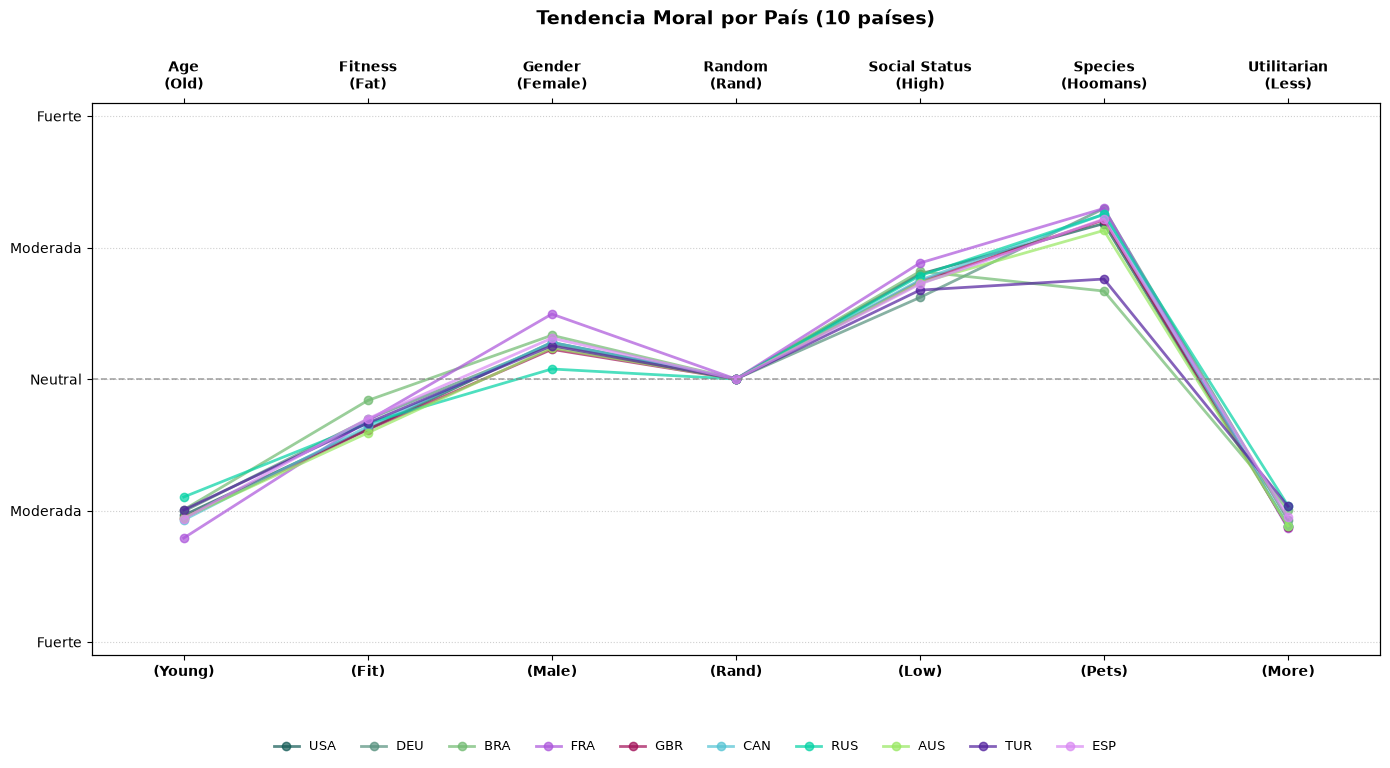

In [35]:
# --- 1. OBTENER TODOS LOS PAÍSES Y GENERAR COLORES ALEATORIOS ---
# Se extraen todos los países únicos del DF
paises_interes = df['country'].value_counts().head(10).index.tolist()

# Se genera un color HEX aleatorio para cada país
colores = {pais: f"#{random.randint(0, 0xFFFFFF):06x}" for pais in paises_interes}

# Filtrar df con todos los países válidos
df_filtrado = df[df['country'].isin(paises_interes)].copy()

# --- 2. CÁLCULO DE MORTALIDAD POR PAÍS Y GRUPO (%) ---
mortalidad_df = (
    (1 - df_filtrado.groupby(['country', 'scenario_type', 'character_group'])['saved'].mean()) * 100
).reset_index(name='mortalidad')

# --- 3. EXTRACCIÓN AUTOMÁTICA DE PARES ---
escenarios_unicos = mortalidad_df['scenario_type'].unique().tolist()

pares_escenarios = {}
for esc in escenarios_unicos:
    grupos_esc = [g for g in mortalidad_df[mortalidad_df['scenario_type'] == esc]['character_group'].unique()]
    if len(grupos_esc) >= 2:
        pares_escenarios[esc] = (grupos_esc[0], grupos_esc[1])
    else:
        pares_escenarios[esc] = (grupos_esc[0], grupos_esc[0])

escenarios = list(pares_escenarios.keys())
sub_arriba = [v[0] for v in pares_escenarios.values()]
sub_abajo = [v[1] for v in pares_escenarios.values()]

# --- 4. CÁLCULO DE TENDENCIA NORMALIZADA (-1.0 a +1.0) ---
datos_tendencia = {pais: [] for pais in paises_interes}

for pais in paises_interes:
    for esc, (grupo_arriba, grupo_abajo) in pares_escenarios.items():
        m_arr = mortalidad_df[
            (mortalidad_df['country'] == pais) & 
            (mortalidad_df['scenario_type'] == esc) & 
            (mortalidad_df['character_group'] == grupo_arriba)
        ]['mortalidad'].mean()

        m_aba = mortalidad_df[
            (mortalidad_df['country'] == pais) & 
            (mortalidad_df['scenario_type'] == esc) & 
            (mortalidad_df['character_group'] == grupo_abajo)
        ]['mortalidad'].mean()

        m_arr = 0 if pd.isna(m_arr) else m_arr
        m_aba = 0 if pd.isna(m_aba) else m_aba

        diff = (m_aba - m_arr) / 100.0
        diff = np.clip(diff, -1.0, 1.0)
        datos_tendencia[pais].append(diff)

# --- 5. GRAFICAR ---
fig, ax_abajo = plt.subplots(figsize=(14, 7))
ax_arriba = ax_abajo.twiny()

x_indices = np.arange(len(escenarios))

# Trazado de líneas para todos los países
for pais in paises_interes:
    ax_abajo.plot(
        x_indices, 
        datos_tendencia[pais], 
        color=colores[pais], 
        linewidth=2, 
        alpha=0.7,  # Transparencia para facilitar visualización si hay muchas líneas
        marker='o', 
        markersize=6, 
        label=pais
    )

# Formato Eje Superior
ax_arriba.set_xticks(x_indices)
ax_arriba.set_xticklabels([f'{esc}\n({sub_arriba[i]})' for i, esc in enumerate(escenarios)], fontsize=10, fontweight='bold')
ax_arriba.set_xlim(-0.5, len(escenarios) - 0.5)

# Formato Eje Inferior
ax_abajo.set_xticks(x_indices)
ax_abajo.set_xticklabels([f'({sub_abajo[i]})' for i in range(len(escenarios))], fontsize=10, fontweight='bold')
ax_abajo.set_xlim(-0.5, len(escenarios) - 0.5)

# Línea Neutra
ax_abajo.axhline(0, color='gray', linestyle='--', linewidth=1.2, alpha=0.7)

# Formato Eje Y
ax_abajo.set_ylim(-1.05, 1.05)
ax_abajo.set_yticks([-1.0, -0.5, 0.0, 0.5, 1.0])
ax_abajo.set_yticklabels(['Fuerte', 'Moderada', 'Neutral', 'Moderada', 'Fuerte'])
ax_abajo.grid(axis='y', linestyle=':', alpha=0.6)

plt.title(f'Tendencia Moral por País ({len(paises_interes)} países)', fontsize=14, fontweight='bold', pad=25)

# Leyenda adaptativa (ajusta columnas según la cantidad de países)
num_columnas = min(10, max(1, len(paises_interes)))
handles, labels = ax_abajo.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=num_columnas, fontsize=9, frameon=False)

plt.tight_layout()
plt.show()